In [5]:
%%writefile requirements.txt
numpy
matplotlib
gymnasium
stable-baselines3
torch
tensorboard

Overwriting requirements.txt


In [6]:
!.venv/bin/python -m pip install -r requirements.txt
!mkdir -p src models logs

In [7]:
%%writefile src/fighter_bt_env.py
from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class FighterVsBTEnv(gym.Env):
    """
    SAC fighter agent vs Behavior Tree enemy.

    Agent 0: SAC
    Agent 1: Behavior Tree

    Action:
        [roll_rate, pitch_rate, thrust]

    Observation:
        my_pos(3), my_vel(3), my_rpy(3),
        enemy_rel_pos(3), enemy_rel_vel(3),
        my_speed, my_energy,
        enemy_speed, enemy_energy,
        my_hp, enemy_hp
    """

    metadata = {"render_modes": []}

    def __init__(self):
        super().__init__()

        self.dt = 0.05
        self.max_steps = 1200
        self.g = 9.81

        self.obs_dim = 21
        self.act_dim = 3

        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = np.array([
            [0.0, 0.0, 35.0],
            [90.0, 20.0, 35.0],
        ], dtype=np.float32)

        self.vel = np.array([
            [30.0, 0.0, 0.0],
            [-25.0, 0.0, 0.0],
        ], dtype=np.float32)

        self.rpy = np.array([
            [0.0, 0.0, 0.0],
            [0.0, 0.0, np.pi],
        ], dtype=np.float32)

        self.pos += self.np_random.uniform(-5.0, 5.0, size=self.pos.shape).astype(np.float32)
        self.pos[:, 2] = np.clip(self.pos[:, 2], 25.0, 45.0)

        self.rpy += self.np_random.uniform(-0.08, 0.08, size=self.rpy.shape).astype(np.float32)

        self.hp = np.array([100.0, 100.0], dtype=np.float32)

        self.step_count = 0
        self.last_dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))

        return self._get_obs(0), {}

    def _rotation_matrix(self, roll, pitch, yaw):
        cr, sr = np.cos(roll), np.sin(roll)
        cp, sp = np.cos(pitch), np.sin(pitch)
        cy, sy = np.cos(yaw), np.sin(yaw)

        Rz = np.array([
            [cy, -sy, 0.0],
            [sy, cy, 0.0],
            [0.0, 0.0, 1.0],
        ])

        Ry = np.array([
            [cp, 0.0, sp],
            [0.0, 1.0, 0.0],
            [-sp, 0.0, cp],
        ])

        Rx = np.array([
            [1.0, 0.0, 0.0],
            [0.0, cr, -sr],
            [0.0, sr, cr],
        ])

        return Rz @ Ry @ Rx

    def _forward(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([1.0, 0.0, 0.0])

    def _right(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([0.0, 1.0, 0.0])

    def _up(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([0.0, 0.0, 1.0])

    def _speed(self, i):
        return float(np.linalg.norm(self.vel[i]))

    def _energy(self, i):
        speed = self._speed(i)
        height = max(float(self.pos[i, 2]), 0.0)
        return self.g * height + 0.5 * speed ** 2

    def _los_angle_deg(self, shooter, target):
        rel = self.pos[target] - self.pos[shooter]
        dist = float(np.linalg.norm(rel))
        to_target = rel / (dist + 1e-6)

        forward = self._forward(shooter)
        cos_theta = np.clip(np.dot(forward, to_target), -1.0, 1.0)
        theta_deg = float(np.degrees(np.arccos(cos_theta)))

        return theta_deg, dist

    def _is_enemy_behind(self, i, enemy):
        """
        True if enemy is behind aircraft i.
        Rear hemisphere means angle between my forward and enemy direction > 90 deg.
        """

        rel = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel)
        to_enemy = rel / (dist + 1e-6)

        forward = self._forward(i)
        rear_score = np.dot(forward, to_enemy)

        return rear_score < -0.15

    def _enemy_on_my_six_score(self, i, enemy):
        """
        Higher when enemy is behind i and pointing toward i.
        """

        rel_enemy_from_me = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel_enemy_from_me)

        to_enemy = rel_enemy_from_me / (dist + 1e-6)
        to_me = -to_enemy

        my_forward = self._forward(i)
        enemy_forward = self._forward(enemy)

        enemy_behind_me = -np.dot(my_forward, to_enemy)
        enemy_aiming_me = np.dot(enemy_forward, to_me)

        score = max(0.0, enemy_behind_me) * max(0.0, enemy_aiming_me)

        return float(score)

    def _compute_damage(self, dist, theta_deg):
        """
        Scaled damage cone.

        Original:
            500~3000 ft, LOS < 1 deg
            500~3500 ft, LOS < 2 deg
            500~4000 ft, LOS < 3 deg

        Sim scale:
            500 ft  -> 5
            3000 ft -> 30
            3500 ft -> 35
            4000 ft -> 40
        """

        # Curriculum-friendly: slightly relaxed cone
        if 5.0 <= dist <= 30.0 and theta_deg < 3.0:
            return 1.0 * (30.0 - dist) / 25.0

        if 5.0 <= dist <= 35.0 and theta_deg < 6.0:
            return 0.3 * (35.0 - dist) / 30.0

        if 5.0 <= dist <= 40.0 and theta_deg < 10.0:
            return 0.1 * (40.0 - dist) / 35.0

        return 0.0

    def _get_obs(self, i):
        j = 1 - i

        rel_pos = self.pos[j] - self.pos[i]
        rel_vel = self.vel[j] - self.vel[i]

        my_speed = self._speed(i)
        enemy_speed = self._speed(j)
        my_energy = self._energy(i)
        enemy_energy = self._energy(j)

        obs = np.concatenate([
            self.pos[i] / 100.0,
            self.vel[i] / 100.0,
            self.rpy[i],
            rel_pos / 100.0,
            rel_vel / 100.0,
            np.array([
                my_speed / 100.0,
                my_energy / 5000.0,
                enemy_speed / 100.0,
                enemy_energy / 5000.0,
                self.hp[i] / 100.0,
                self.hp[j] / 100.0,
            ], dtype=np.float32),
        ])

        return obs.astype(np.float32)

    def _apply_action(self, i, action):
        action = np.asarray(action, dtype=np.float32)

        roll_rate, pitch_rate, thrust = action

        self.rpy[i, 0] += float(roll_rate) * self.dt
        self.rpy[i, 1] += float(pitch_rate) * self.dt

        self.rpy[i, 0] = np.clip(self.rpy[i, 0], -1.25, 1.25)
        self.rpy[i, 1] = np.clip(self.rpy[i, 1], -0.75, 0.75)

        speed = self._speed(i)

        # Bank-turn yaw dynamics.
        turn_rate = self.g * np.tan(self.rpy[i, 0]) / (speed + 1e-6)
        turn_rate = np.clip(turn_rate, -1.2, 1.2)

        self.rpy[i, 2] += turn_rate * self.dt

        forward = self._forward(i)
        speed = self._speed(i)

        thrust_accel = forward * float(thrust) * 38.0
        gravity = np.array([0.0, 0.0, -self.g])
        drag = -0.010 * self.vel[i] * speed

        accel = thrust_accel + gravity + drag

        self.vel[i] = self.vel[i] + accel * self.dt
        self.pos[i] = self.pos[i] + self.vel[i] * self.dt

    def behavior_tree_enemy_action(self):
        """
        Improved Behavior Tree enemy.

        Priority:
            1. Ground avoidance
            2. Low speed recovery
            3. Defensive break only if SAC agent is behind enemy
            4. Stable aim when in firing cone
            5. Chase / pure pursuit
            6. Patrol
        """

        i = 1
        j = 0

        rel = self.pos[j] - self.pos[i]
        dist = float(np.linalg.norm(rel))
        to_agent = rel / (dist + 1e-6)

        forward = self._forward(i)
        right = self._right(i)
        up = self._up(i)

        heading_align = float(np.dot(forward, to_agent))
        lateral_error = float(np.dot(right, to_agent))
        vertical_error = float(np.dot(up, to_agent))

        speed = self._speed(i)
        height = float(self.pos[i, 2])

        enemy_los_deg, _ = self._los_angle_deg(i, j)

        sac_is_behind_enemy = self._is_enemy_behind(i, j)
        danger_score = self._enemy_on_my_six_score(i, j)

        # 1. Ground avoidance
        if height < 18.0:
            return np.array([0.0, 1.0, 1.0], dtype=np.float32)

        # 2. Low speed recovery
        if speed < 16.0:
            return np.array([0.0, -0.15, 1.0], dtype=np.float32)

        # 3. Defensive break only when SAC is behind enemy.
        if sac_is_behind_enemy and danger_score > 0.25:
            side = -np.sign(lateral_error + 1e-6)

            roll_rate = np.clip(side * 1.0, -1.0, 1.0)
            pitch_rate = 0.35
            thrust = 1.0

            return np.array([roll_rate, pitch_rate, thrust], dtype=np.float32)

        # 4. Stable aim when close to firing cone.
        if 5.0 < dist < 45.0 and enemy_los_deg < 12.0:
            roll_rate = np.clip(lateral_error * 1.4, -0.7, 0.7)
            pitch_rate = np.clip(vertical_error * 1.3, -0.6, 0.6)
            thrust = 0.75

            if enemy_los_deg < 5.0:
                thrust = 0.65

            return np.array([roll_rate, pitch_rate, thrust], dtype=np.float32)

        # 5. Chase.
        if dist < 170.0:
            roll_rate = np.clip(lateral_error * 2.7, -1.0, 1.0)
            pitch_rate = np.clip(vertical_error * 2.0, -1.0, 1.0)

            thrust = 0.85
            if heading_align > 0.8:
                thrust = 1.0

            return np.array([roll_rate, pitch_rate, thrust], dtype=np.float32)

        # 6. Patrol.
        return np.array([0.25, 0.0, 0.65], dtype=np.float32)

    def step(self, action):
        agent_action = np.asarray(action, dtype=np.float32)
        enemy_action = self.behavior_tree_enemy_action()

        prev_dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))

        self._apply_action(0, agent_action)
        self._apply_action(1, enemy_action)

        self.step_count += 1

        dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))
        progress = prev_dist - dist

        agent_los_deg, agent_dist = self._los_angle_deg(0, 1)
        enemy_los_deg, enemy_dist = self._los_angle_deg(1, 0)

        agent_damage = self._compute_damage(agent_dist, agent_los_deg)
        enemy_damage = self._compute_damage(enemy_dist, enemy_los_deg)

        damage_scale = 1.2
        self.hp[1] -= agent_damage * damage_scale
        self.hp[0] -= enemy_damage * damage_scale
        self.hp = np.clip(self.hp, 0.0, 100.0)

        my_energy = self._energy(0)
        enemy_energy = self._energy(1)
        energy_adv = my_energy - enemy_energy

        speed = self._speed(0)
        height = float(self.pos[0, 2])

        rel = self.pos[1] - self.pos[0]
        to_enemy = rel / (np.linalg.norm(rel) + 1e-6)
        forward = self._forward(0)

        heading_align = float(np.dot(forward, to_enemy))
        closing_speed = float(np.dot(self.vel[0], to_enemy))

        enemy_behind_agent = self._is_enemy_behind(0, 1)
        danger_score = self._enemy_on_my_six_score(0, 1)

        action_cost = float(np.sum(agent_action ** 2))

        reward = 0.0

        # Main combat reward.
        reward += 130.0 * agent_damage
        reward -= 130.0 * enemy_damage

        # Aim and pursuit.
        reward += 4.0 * heading_align
        reward += 0.04 * closing_speed
        reward += 4.0 * progress
        reward -= 0.018 * dist

        # Proper engagement distance.
        if 10.0 < dist < 35.0:
            reward += 3.0

        if dist < 5.0:
            reward -= 8.0

        # Escape is rewarded only when enemy is behind me.
        if enemy_behind_agent and danger_score > 0.25:
            reward += 2.0 * danger_score

            # In danger, gaining distance is good.
            if progress < 0.0:
                reward += 3.0 * (-progress)

            # In danger, energy is more valuable.
            reward += 0.00012 * my_energy
        else:
            # Otherwise, do not reward running away.
            if progress < 0.0:
                reward -= 2.0 * (-progress)

        # Energy advantage, weak.
        reward += 0.00004 * energy_adv

        # Speed envelope.
        if 24.0 < speed < 75.0:
            reward += 0.8

        if speed < 10.0:
            reward -= 6.0

        if speed > 145.0:
            reward -= 10.0

        # Altitude safety.
        if height < 12.0:
            reward -= 4.0

        reward -= 0.001 * action_cost

        terminated = False
        truncated = False

        if self.hp[1] <= 0.0:
            reward += 120.0
            terminated = True

        if self.hp[0] <= 0.0:
            reward -= 120.0
            terminated = True

        if height < 0.0:
            reward -= 100.0
            terminated = True

        if self.step_count >= self.max_steps:
            truncated = True

        obs = self._get_obs(0)

        info = {
            "dist": float(dist),
            "agent_hp": float(self.hp[0]),
            "enemy_hp": float(self.hp[1]),
            "agent_damage": float(agent_damage),
            "enemy_damage": float(enemy_damage),
            "agent_los_deg": float(agent_los_deg),
            "enemy_los_deg": float(enemy_los_deg),
            "agent_energy": float(my_energy),
            "enemy_energy": float(enemy_energy),
            "agent_speed": float(speed),
            "enemy_speed": float(self._speed(1)),
            "agent_pos": self.pos[0].copy(),
            "enemy_pos": self.pos[1].copy(),
            "agent_rpy": self.rpy[0].copy(),
            "enemy_rpy": self.rpy[1].copy(),
            "agent_action": agent_action.copy(),
            "enemy_action": enemy_action.copy(),
            "enemy_behind_agent": bool(enemy_behind_agent),
            "danger_score": float(danger_score),
        }

        return obs, float(reward), terminated, truncated, info

Overwriting src/fighter_bt_env.py


In [8]:
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from src.fighter_bt_env import FighterVsBTEnv
import torch

env = FighterVsBTEnv()
env = Monitor(env)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    device=device,   # 추가
    learning_rate=3e-4,
    buffer_size=500_000,
    learning_starts=10_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    tensorboard_log="logs/sac_vs_bt_bankturn_escape_only",
)

model.learn(total_timesteps=50_000)

model.save("models/sac_vs_bt_bankturn_escape_only")

device: cuda
Using cuda device
Wrapping the env in a DummyVecEnv.
Logging to logs/sac_vs_bt_bankturn_escape_only/SAC_5


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 84        |
|    ep_rew_mean     | -1.47e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 1500      |
|    time_elapsed    | 0         |
|    total_timesteps | 336       |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 76.6      |
|    ep_rew_mean     | -1.29e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 1528      |
|    time_elapsed    | 0         |
|    total_timesteps | 613       |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 73.5     |
|    ep_rew_mean     | -1.2e+03 |
| time/              |          |
|    episodes        | 12       |
|    fps             | 1569     |
|    time_elapsed    | 0        |
|    total_timesteps | 882  

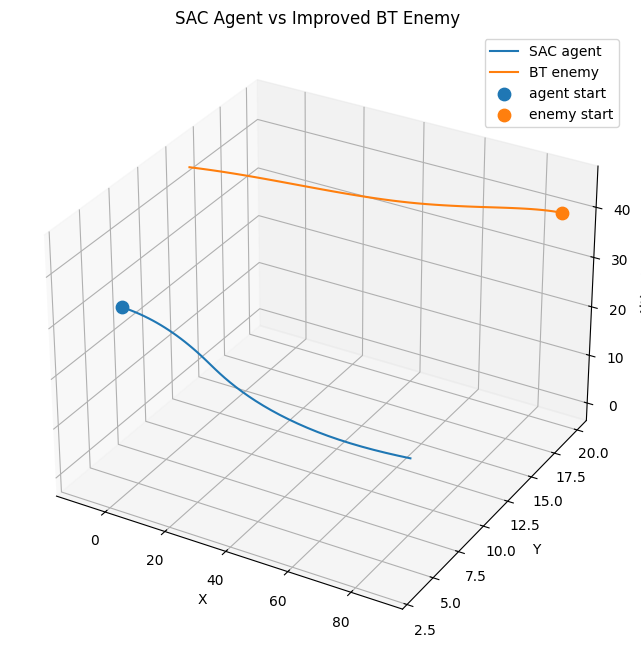

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import SAC
from src.fighter_bt_env import FighterVsBTEnv


env = FighterVsBTEnv()
env.max_steps = 1600

model = SAC.load("models/sac_vs_bt_bankturn_escape_only")

obs, _ = env.reset()

agent_traj = []
enemy_traj = []

agent_hp = []
enemy_hp = []

agent_damage = []
enemy_damage = []

agent_los = []
enemy_los = []

dists = []
agent_energy = []
enemy_energy = []
danger_scores = []

for _ in range(env.max_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    agent_traj.append(info["agent_pos"])
    enemy_traj.append(info["enemy_pos"])

    agent_hp.append(info["agent_hp"])
    enemy_hp.append(info["enemy_hp"])

    agent_damage.append(info["agent_damage"])
    enemy_damage.append(info["enemy_damage"])

    agent_los.append(info["agent_los_deg"])
    enemy_los.append(info["enemy_los_deg"])

    dists.append(info["dist"])
    agent_energy.append(info["agent_energy"])
    enemy_energy.append(info["enemy_energy"])
    danger_scores.append(info["danger_score"])

    if terminated or truncated:
        break

agent_traj = np.array(agent_traj)
enemy_traj = np.array(enemy_traj)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(agent_traj[:, 0], agent_traj[:, 1], agent_traj[:, 2], label="SAC agent")
ax.plot(enemy_traj[:, 0], enemy_traj[:, 1], enemy_traj[:, 2], label="BT enemy")

ax.scatter(agent_traj[0, 0], agent_traj[0, 1], agent_traj[0, 2], s=80, label="agent start")
ax.scatter(enemy_traj[0, 0], enemy_traj[0, 1], enemy_traj[0, 2], s=80, label="enemy start")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
ax.set_title("SAC Agent vs Improved BT Enemy")
ax.legend()
plt.show()

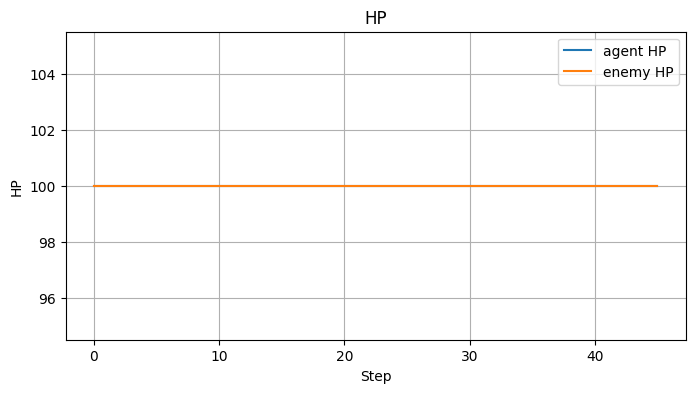

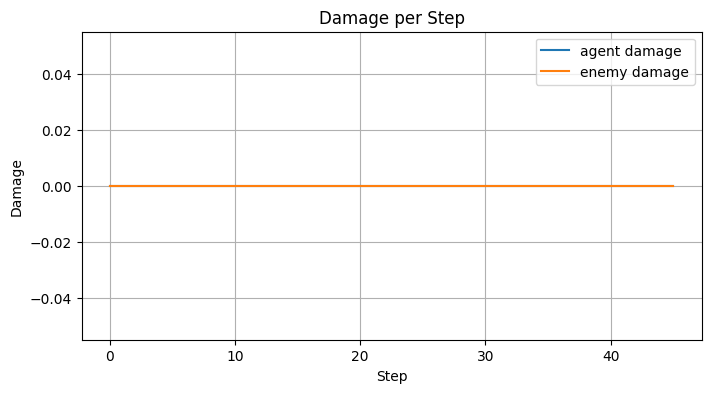

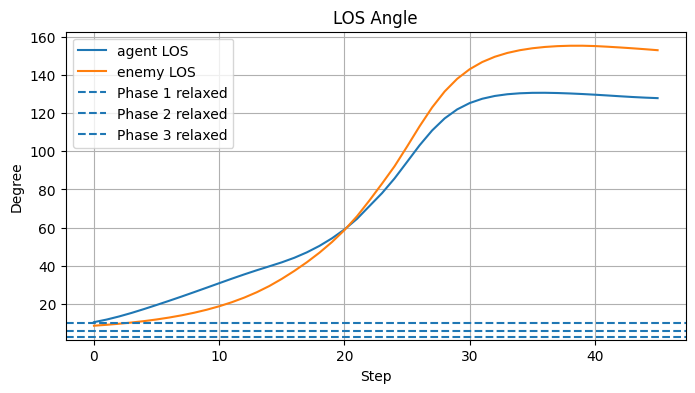

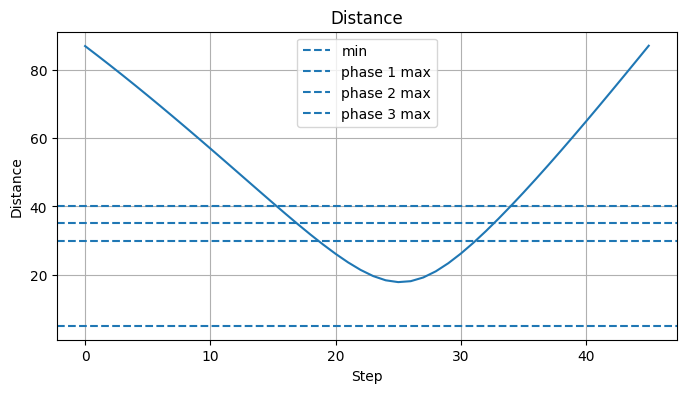

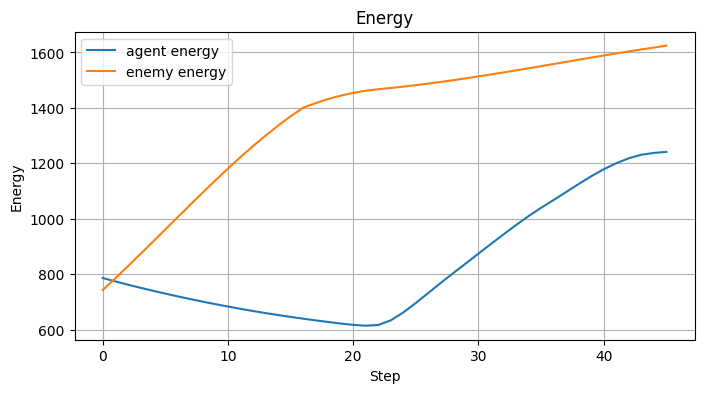

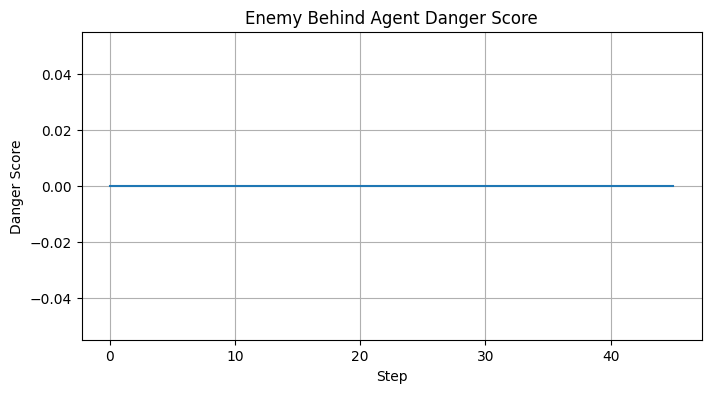

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(agent_hp, label="agent HP")
plt.plot(enemy_hp, label="enemy HP")
plt.title("HP")
plt.xlabel("Step")
plt.ylabel("HP")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_damage, label="agent damage")
plt.plot(enemy_damage, label="enemy damage")
plt.title("Damage per Step")
plt.xlabel("Step")
plt.ylabel("Damage")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_los, label="agent LOS")
plt.plot(enemy_los, label="enemy LOS")
plt.axhline(3.0, linestyle="--", label="Phase 1 relaxed")
plt.axhline(6.0, linestyle="--", label="Phase 2 relaxed")
plt.axhline(10.0, linestyle="--", label="Phase 3 relaxed")
plt.title("LOS Angle")
plt.xlabel("Step")
plt.ylabel("Degree")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(dists)
plt.axhline(5.0, linestyle="--", label="min")
plt.axhline(30.0, linestyle="--", label="phase 1 max")
plt.axhline(35.0, linestyle="--", label="phase 2 max")
plt.axhline(40.0, linestyle="--", label="phase 3 max")
plt.title("Distance")
plt.xlabel("Step")
plt.ylabel("Distance")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_energy, label="agent energy")
plt.plot(enemy_energy, label="enemy energy")
plt.title("Energy")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(danger_scores)
plt.title("Enemy Behind Agent Danger Score")
plt.xlabel("Step")
plt.ylabel("Danger Score")
plt.grid(True)
plt.show()